Import

In [1]:
import numpy as np
import matplotlib.pyplot as plt

print("INTERPOLASI POLINOMIAL - METODE LAGRANGE")
print("="*40)

INTERPOLASI POLINOMIAL - METODE LAGRANGE


Fungsi Lagrange

In [2]:
def lagrange_basis(X, i, x):
    L = 1
    for j in range(len(X)):
        if i != j:
            L *= (x - X[j]) / (X[i] - X[j])
    return L


def lagrange(X, Y, x):
    return sum(Y[i] * lagrange_basis(X, i, x) for i in range(len(X)))

Input Data

In [3]:
X = [2, 4, 5, 6, 7]
Y = [3, 5, 1, 6, 9]
x_query = 3

print("DATA:")
for x, y in zip(X, Y):
    print(f"x = {x}, f(x) = {y}")

DATA:
x = 2, f(x) = 3
x = 4, f(x) = 5
x = 5, f(x) = 1
x = 6, f(x) = 6
x = 7, f(x) = 9


Tabel Interaktif

In [4]:
print("TABEL PERHITUNGAN")
print("-"*50)

total = 0

for i in range(len(X)):
    Li = lagrange_basis(X, i, x_query)
    yiLi = Y[i] * Li
    total += yiLi

    print(f"L{i}({x_query}) = {Li:.6f} | kontribusi = {yiLi:.6f}")

print("-"*50)
print(f"Hasil akhir f({x_query}) = {total:.6f}")

TABEL PERHITUNGAN
--------------------------------------------------
L0(3) = 0.200000 | kontribusi = 0.600000
L1(3) = 2.000000 | kontribusi = 10.000000
L2(3) = -2.000000 | kontribusi = -2.000000
L3(3) = 1.000000 | kontribusi = 6.000000
L4(3) = -0.200000 | kontribusi = -1.800000
--------------------------------------------------
Hasil akhir f(3) = 12.800000


Visualisasi Lagrange

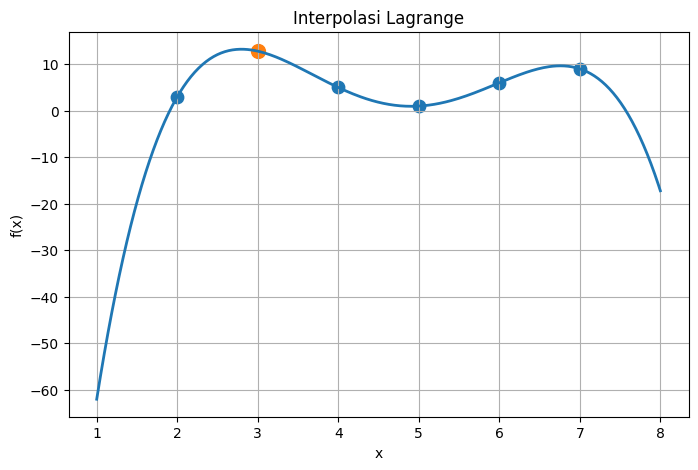

In [5]:
x_range = np.linspace(min(X)-1, max(X)+1, 300)
y_range = [lagrange(X, Y, xi) for xi in x_range]

plt.figure(figsize=(8,5))
plt.plot(x_range, y_range, linewidth=2)
plt.scatter(X, Y, s=80)
plt.scatter(x_query, total, s=100)

plt.title("Interpolasi Lagrange")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()
plt.show()

Interpolasi Newton

In [6]:
print("INTERPOLASI POLINOMIAL - METODE NEWTON")
print("="*40)

INTERPOLASI POLINOMIAL - METODE NEWTON


Fungsi Newton

In [7]:
def divided_diff(X, Y):
    n = len(X)
    table = np.zeros((n, n))
    
    table[:,0] = Y

    for j in range(1, n):
        for i in range(n - j):
            table[i][j] = (table[i+1][j-1] - table[i][j-1]) / (X[i+j] - X[i])
    
    return table


def newton(X, table, x):
    result = table[0][0]
    product = 1

    for i in range(1, len(X)):
        product *= (x - X[i-1])
        result += table[0][i] * product
    
    return result

Perhitungan Newton

In [8]:
table = divided_diff(X, Y)

print("TABEL:")
print(table)

y_newton = newton(X, table, x_query)

print("HASIL NEWTON:")
print(f"f({x_query}) = {y_newton:.6f}")

TABEL:
[[ 3.          1.         -1.66666667  1.54166667 -0.675     ]
 [ 5.         -4.          4.5        -1.83333333  0.        ]
 [ 1.          5.         -1.          0.          0.        ]
 [ 6.          3.          0.          0.          0.        ]
 [ 9.          0.          0.          0.          0.        ]]
HASIL NEWTON:
f(3) = 12.800000


Visualisasi Newton

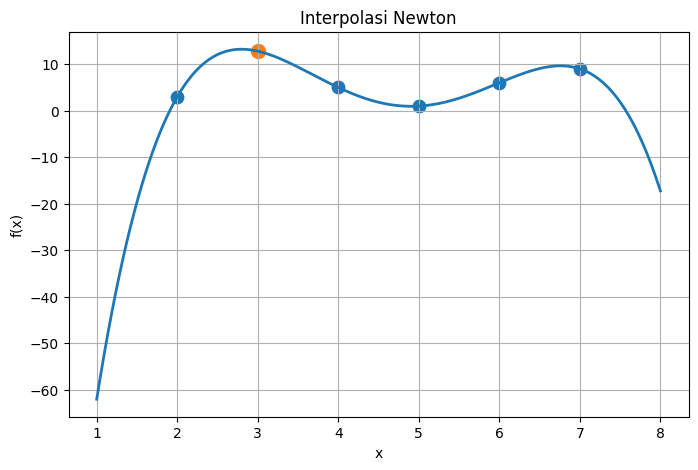

In [9]:
x_range = np.linspace(min(X)-1, max(X)+1, 300)
y_new = [newton(X, table, xi) for xi in x_range]

plt.figure(figsize=(8,5))
plt.plot(x_range, y_new, linewidth=2)
plt.scatter(X, Y, s=80)
plt.scatter(x_query, y_newton, s=100)

plt.title("Interpolasi Newton")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()
plt.show()